# Практическое занятие №2: Градиентный спуск и оптимизаторы
**Цели занятия:**
- Научиться визуализировать функции потерь двух переменных (3D и линии уровня).
- Реализовать простой градиентный спуск (SGD) с помощью PyTorch и проследить траекторию оптимизации.
- Познакомиться с основными оптимизаторами из семейства gradient descent: SGD с моментом, RMSprop, Adam.
- Исследовать влияние скорости обучения (learning rate) на сходимость.

Слова "**Задание**" выделены жирным шрифтом по тексту.

## 1. Импорт необходимых библиотек
Установка и импорт:
- `torch` для автоматического дифференцирования и оптимизаторов.
- `numpy` для численных операций.
- `matplotlib` для построения графиков (3D, контурные, анимация).
- `ipywidgets` (опционально) для интерактивности.

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import animation
from IPython.display import HTML
import warnings
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from seaborn import axes_style

warnings.filterwarnings('ignore')

# Для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

## 2. Функции для визуализации
Определим две классические тестовые функции:
- **Функция Розенброка** (Rosenbrock) — «овражная» функция, сложная для оптимизации:
  $$f(x,y) = (a - x)^2 + b\,(y - x^2)^2,\quad a=1,\; b=100.$$
  Глобальный минимум в точке $(1,1)$.
- **Функция Химмельблау** (Himmelblau) — с несколькими локальными минимумами:
  $$f(x,y) = (x^2 + y - 11)^2 + (x + y^2 - 7)^2.$$
  Четыре локальных минимума: $(3,2)$, $(-2.805,3.131)$, $(-3.779,-3.283)$, $(3.584,-1.848)$.

In [10]:
def rosenbrock(x, y, a=1, b=100):
    return (a - x)**2 + b * (y - x**2)**2

def himmelblau(x, y):
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

# Создадим сетку для построения графиков
x = np.linspace(-2, 2, 100)
y = np.linspace(-1, 3, 100)
X, Y = np.meshgrid(x, y)
Z_rosen = rosenbrock(X, Y)

# Для Химмельблау возьмём более широкий диапазон
x_h = np.linspace(-5, 5, 100)
y_h = np.linspace(-5, 5, 100)
X_h, Y_h = np.meshgrid(x_h, y_h)
Z_himm = himmelblau(X_h, Y_h)

### 2.1 3D-визуализация функций
**Задание 1**: построить поверхности функций Розенброка и Химмельблау в 3D с возможностью интерактивного вращения. Обратите внимание на овраг у Розенброка и несколько впадин у Химмельблау.

Пример можно взять из лекции (библиотека plotly).

In [11]:
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'surface'}, {'type': 'surface'}]],
    subplot_titles=('Функция Розенброка', 'Функция Химмельблау')
)

# Функция Розенброка
fig.add_trace(
    go.Surface(x=X, y=Y, z=Z_rosen, colorscale='Viridis'),
    row=1, col=1
)

# Функция Химмельблау
fig.add_trace(
    go.Surface(x=X_h, y=Y_h, z=Z_himm, colorscale='Plasma'),
    row=1, col=2
)

fig.update_layout(
    title='3D-визуализация функций Розенброка и Химмельблау',
    height=500,
    width=1000,
    scene=dict(
        xaxis_title='x',
        yaxis_title='y',
        zaxis_title='f(x, y)',
        camera=dict(eye=dict(x=1.8, y=1.8, z=1.4))
    ),
    scene2=dict(
        xaxis_title='x',
        yaxis_title='y',
        zaxis_title='f(x, y)',
        camera=dict(eye=dict(x=2.0, y=2.0, z=1.6))
    ),

)

fig.show()

### 2.2 Контурные графики (линии уровня)
**Задание 2.** Нарисовать контурные графиках и точки глобальных (или локальных) минимумов на них.
Можно matplotlib или seaborn. (Проявить фантазию в оформлении!)

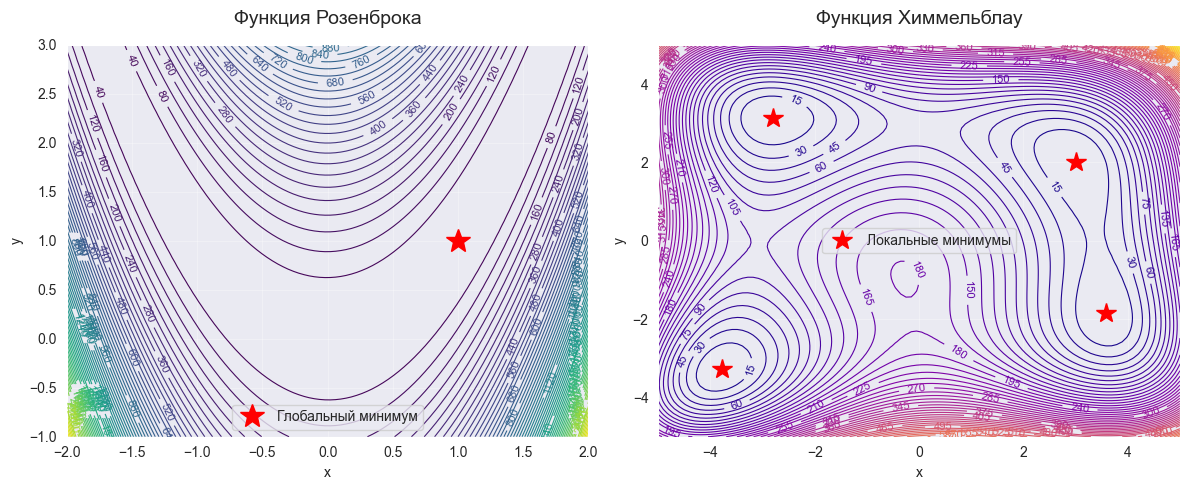

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

### Контурные графики
cs1 = axes[0].contour(X, Y, Z_rosen, levels=80, cmap='viridis', linewidths=0.8)
axes[0].clabel(cs1, inline=True, fontsize=8, fmt='%.0f')
axes[0].set_title('Функция Розенброка', fontsize=14, pad=15)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].grid(True, alpha=0.3)

axes[0].plot(1, 1, 'r*', markersize=18, label='Глобальный минимум')
axes[0].legend()

cs2 = axes[1].contour(X_h, Y_h, Z_himm, levels=60, cmap='plasma', linewidths=0.8)
axes[1].clabel(cs2, inline=True, fontsize=8, fmt='%.0f')
axes[1].set_title('Функция Химмельблау', fontsize=14, pad=15)
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].grid(True, alpha=0.3)

minima = [(3, 2), (-2.805, 3.131), (-3.779, -3.283), (3.584, -1.848)]
for px, py in minima:
    axes[1].plot(px, py, 'r*', markersize=15)

axes[1].plot([], [], 'r*', markersize=15, label='Локальные минимумы')
axes[1].legend()

plt.tight_layout()
plt.show()

**Задание 3.** Изучите полученные графики. Почему функция Розенброка считается сложной для градиентного спуска? (Ответьте в ячейке ниже)

*Ваш ответ:*  
Сложная из-за узкого, сильно изогнутого оврага в форме параболы. Вдоль оврага градиент очень мал, что замедляет движение к минимуму

## 3. Реализация градиентного спуска (SGD) с помощью PyTorch

Будем минимизировать функцию двух переменных, используя автоматическое дифференцирование PyTorch. Создадим тензоры с включённым `requires_grad=True` и на каждом шаге будем обновлять их с помощью правила SGD:
$$\theta_{t+1} = \theta_t - \eta \nabla f(\theta_t).$$

В цикле оптимизации необходимо:
1. Вычислить значение функции.
2. Вызвать `.backward()` для вычисления градиентов.
3. Обновить параметры вручную (или с помощью оптимизатора).
4. Обнулить градиенты (`.grad.zero_()`).

Напишем функцию, которая выполняет заданное количество шагов SGD и записывает траекторию.

In [13]:
def sgd_trajectory(func, x0, y0, lr=0.01, steps=50):
    """
    Выполняет SGD для функции func(x,y) от двух переменных.
    Возвращает списки x_hist, y_hist, f_hist.
    """
    x = torch.tensor(x0, requires_grad=True, dtype=torch.float32)
    y = torch.tensor(y0, requires_grad=True, dtype=torch.float32)

    x_hist, y_hist, f_hist = [], [], []

    for i in range(steps):
        # Вычисляем функцию
        f = func(x, y)
        # Сохраняем историю (отсоединяем от графа вычислений)
        x_hist.append(x.item())
        y_hist.append(y.item())
        f_hist.append(f.item())

        # Градиенты
        f.backward()

        # Обновление вручную (SGD)
        with torch.no_grad():
            x -= lr * x.grad
            y -= lr * y.grad

        # Обнуляем градиенты
        x.grad.zero_()
        y.grad.zero_()

    return x_hist, y_hist, f_hist

Протестируем на функции Розенброка с начальной точкой (-1.5, 1.5), learning rate = 0.001 и 200 шагов. Построим траекторию на контурном графике.

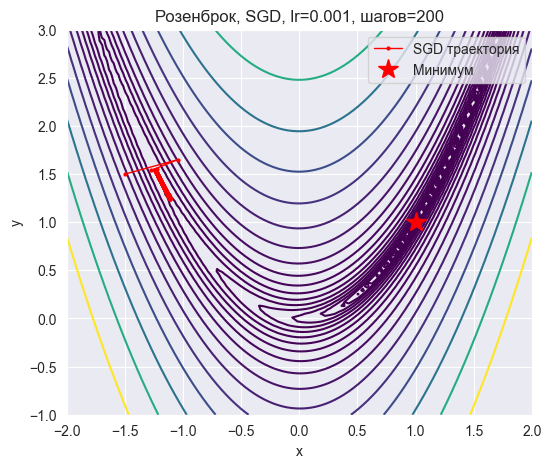

In [14]:
x0, y0 = -1.5, 1.5
lr = 0.001
steps = 200

x_hist, y_hist, f_hist = sgd_trajectory(rosenbrock, x0, y0, lr, steps)

# Визуализация
plt.figure(figsize=(6,5))
plt.contour(X, Y, Z_rosen, levels=np.logspace(-1, 3, 20), cmap='viridis')
plt.plot(x_hist, y_hist, 'r.-', markersize=4, linewidth=1, label='SGD траектория')
plt.plot(1, 1, 'r*', markersize=15, label='Минимум')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Розенброк, SGD, lr={lr}, шагов={steps}')
plt.legend()
plt.show()

**Задание 4.** Поэкспериментируйте с learning rate и начальной точкой. Попробуйте для обеих функций:
- Попробовать 5 различных значений learning rate (например, 0.01, 0.05). Что происходит?
- Попробовать 5 различных начальных точек, например (0, 2) или (-1, -1) или случаным образом выбранных, надётся ли действительный глобальный минимум?

Результирующие графики всех экспериментов сохраните в отчётном блокноте.



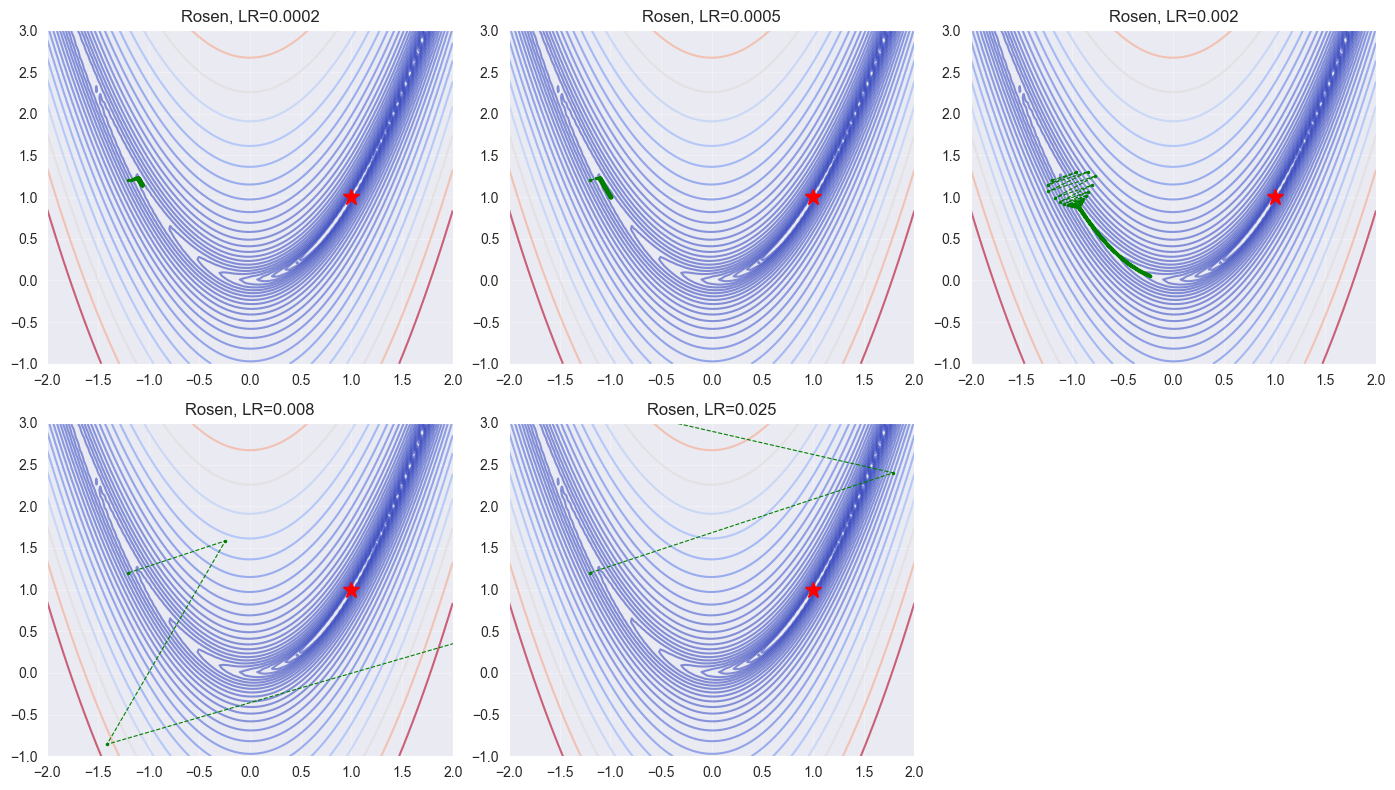

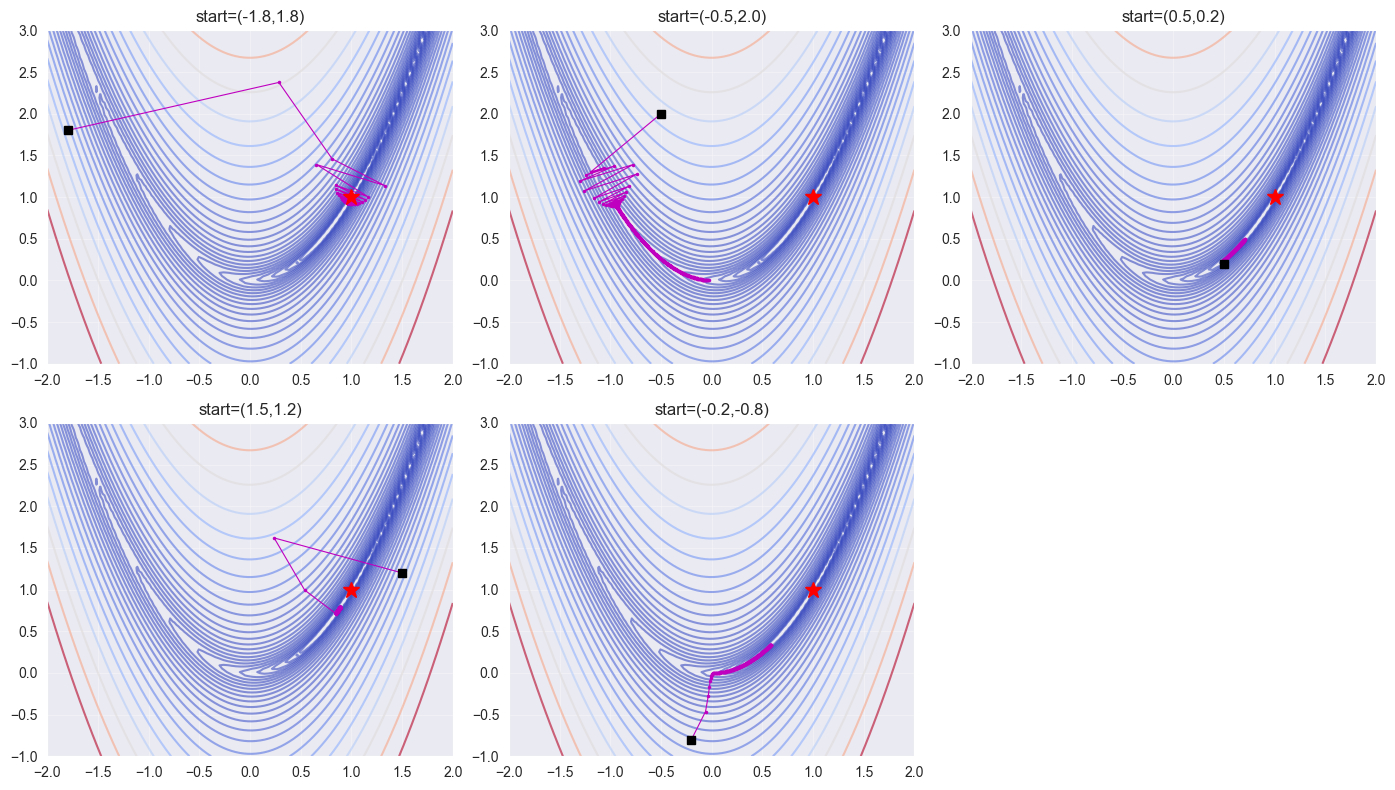

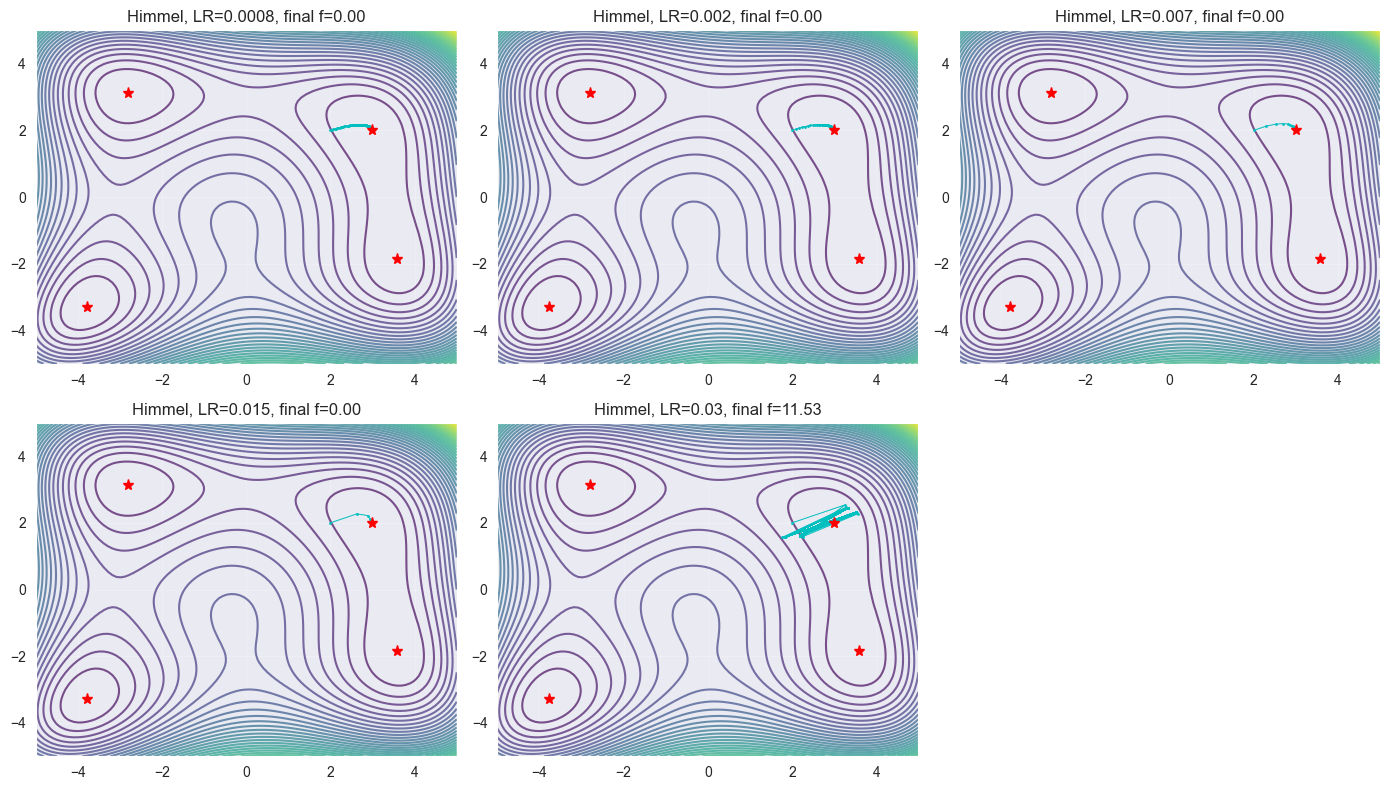

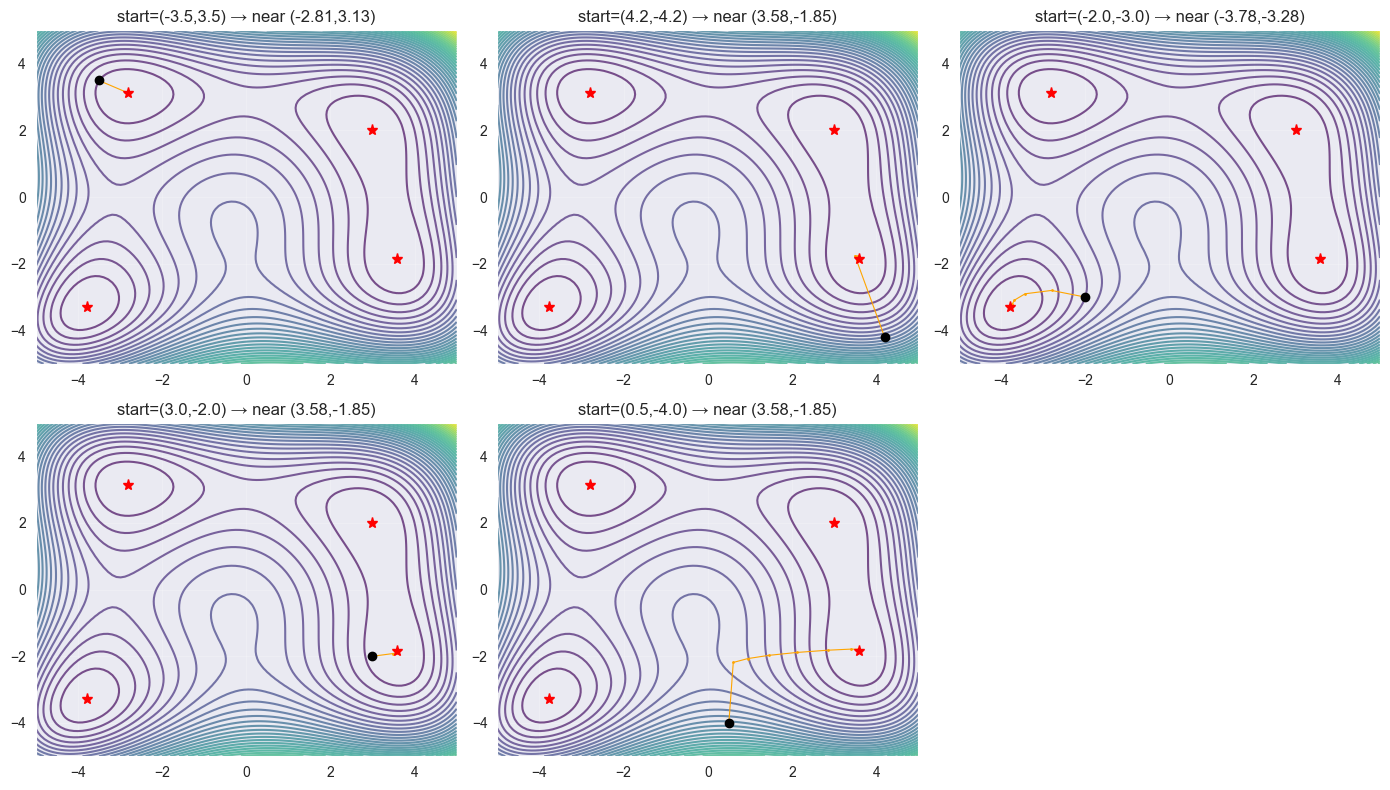

In [15]:
def rosen(x, y):
    return (1 - x)**2 + 100 * (y - x**2)**2

def himmel(x, y):
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

# =================================
# ЭКСПЕРИМЕНТ 1: Розенброк – разные LR
# =================================
start_ros = (-1.2, 1.2)          # другая начальная точка
lr_list_ros = [0.0002, 0.0005, 0.002, 0.008, 0.025]
steps_ros = 300

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for idx, lr in enumerate(lr_list_ros):
    ax = axes[idx]
    xs, ys, _ = sgd_trajectory(rosen, start_ros[0], start_ros[1], lr, steps_ros)
    cs = ax.contour(X, Y, Z_rosen, levels=np.logspace(-0.5, 3, 25), cmap='coolwarm', alpha=0.6)
    ax.plot(xs, ys, 'g.--', markersize=3, linewidth=0.8, label=f'LR={lr}')
    ax.plot(1, 1, 'r*', markersize=12, label='min')
    ax.set_title(f'Rosen, LR={lr}')
    ax.set_xlim(-2, 2); ax.set_ylim(-1, 3)
    ax.grid(True, alpha=0.3)
# Убираем пустой подграфик (если есть 6-й)
if len(lr_list_ros) < len(axes):
    axes[-1].axis('off')
plt.tight_layout()
plt.show()

# =================================
# ЭКСПЕРИМЕНТ 2: Розенброк – разные стартовые точки
# =================================
start_points_ros = [(-1.8, 1.8), (-0.5, 2.0), (0.5, 0.2), (1.5, 1.2), (-0.2, -0.8)]
fixed_lr_ros = 0.002
steps_ros = 350

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for idx, (x0, y0) in enumerate(start_points_ros):
    ax = axes[idx]
    xs, ys, _ = sgd_trajectory(rosen, x0, y0, fixed_lr_ros, steps_ros)
    ax.contour(X, Y, Z_rosen, levels=np.logspace(-0.5, 3, 25), cmap='coolwarm', alpha=0.6)
    ax.plot(xs, ys, 'm.-', markersize=3, linewidth=0.8)
    ax.plot(x0, y0, 'ks', markersize=6, label='start')
    ax.plot(1, 1, 'r*', markersize=12, label='min')
    ax.set_title(f'start=({x0:.1f},{y0:.1f})')
    ax.set_xlim(-2, 2); ax.set_ylim(-1, 3)
    ax.grid(True, alpha=0.3)
if len(start_points_ros) < len(axes):
    axes[-1].axis('off')
plt.tight_layout()
plt.show()

# =================================
# ЭКСПЕРИМЕНТ 3: Химмельблау – разные LR
# =================================
start_him = (2.0, 2.0)           # другая начальная точка
lr_list_him = [0.0008, 0.002, 0.007, 0.015, 0.03]
steps_him = 250

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for idx, lr in enumerate(lr_list_him):
    ax = axes[idx]
    xs, ys, fs = sgd_trajectory(himmel, start_him[0], start_him[1], lr, steps_him)
    ax.contour(X_h, Y_h, Z_himm, levels=40, cmap='viridis', alpha=0.7)
    ax.plot(xs, ys, 'c.-', markersize=2, linewidth=0.7)
    # отметим все 4 минимума
    for mx, my in minima:
        ax.plot(mx, my, 'r*', markersize=8)
    ax.set_title(f'Himmel, LR={lr}, final f={fs[-1]:.2f}')
    ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
    ax.grid(True, alpha=0.2)
if len(lr_list_him) < len(axes):
    axes[-1].axis('off')
plt.tight_layout()
plt.show()

# =================================
# ЭКСПЕРИМЕНТ 4: Химмельблау – разные стартовые точки
# =================================
start_points_him = [(-3.5, 3.5), (4.2, -4.2), (-2.0, -3.0), (3.0, -2.0), (0.5, -4.0)]
fixed_lr_him = 0.01
steps_him = 300

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for idx, (x0, y0) in enumerate(start_points_him):
    ax = axes[idx]
    xs, ys, fs = sgd_trajectory(himmel, x0, y0, fixed_lr_him, steps_him)
    # определяем, к какому минимуму пришли
    dists = [np.hypot(xs[-1]-mx, ys[-1]-my) for mx, my in minima]
    nearest = minima[np.argmin(dists)]
    ax.contour(X_h, Y_h, Z_himm, levels=40, cmap='viridis', alpha=0.7)
    ax.plot(xs, ys, 'orange', linestyle='-', marker='.', markersize=2, linewidth=0.8)
    ax.plot(x0, y0, 'ko', markersize=6, label='start')
    for mx, my in minima:
        ax.plot(mx, my, 'r*', markersize=8)
    ax.set_title(f'start=({x0:.1f},{y0:.1f}) → near ({nearest[0]:.2f},{nearest[1]:.2f})')
    ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
    ax.grid(True, alpha=0.2)
if len(start_points_him) < len(axes):
    axes[-1].axis('off')
plt.tight_layout()
plt.show()

## 4. Сравнение оптимизаторов из torch.optim

PyTorch предоставляет готовые реализации многих оптимизаторов: SGD (с momentum и nesterov), RMSprop, Adam и др. Мы можем использовать их, передав параметры модели. В нашем случае модель — это просто два тензора x и y.

Напишем функцию, которая принимает оптимизатор (например, `torch.optim.SGD`), его параметры и возвращает траекторию.

In [16]:
def optimizer_trajectory(func, x0, y0, optim_class, optim_kwargs, steps=100):
    """
    Метод для конкретного оптимизатора и конкретной оптимизируемой функции реализует градиентный спуск.
    optim_class: наименование класса оптимизатора строкой (SGD, Adam, RMSprop)
    optim_kwargs: словарь параметров, например {'lr':0.01, 'momentum':0.9}
    """
    x = torch.tensor(x0, requires_grad=True, dtype=torch.float32)
    y = torch.tensor(y0, requires_grad=True, dtype=torch.float32)

    # Создаём оптимизатор, передав список параметров
    optimizer = optim_class([x, y], **optim_kwargs)

    x_hist, y_hist, f_hist = [], [], []

    for i in range(steps):
        optimizer.zero_grad()
        f = func(x, y)
        f.backward()
        # собственно обновление значений подбираемых параметров
        optimizer.step()

        x_hist.append(x.item())
        y_hist.append(y.item())
        f_hist.append(f.item())

    return x_hist, y_hist, f_hist

### 4.1 Сравнение на функции Розенброка
Возьмём начальную точку (-1.5, 1.5), 100 шагов, и сравним:
- SGD (learning rate = 0.001)
- SGD с моментом (lr=0.001, momentum=0.9)
- RMSprop (lr=0.01)
- Adam (lr=0.01)

Построим все траектории на одном контурном графике.

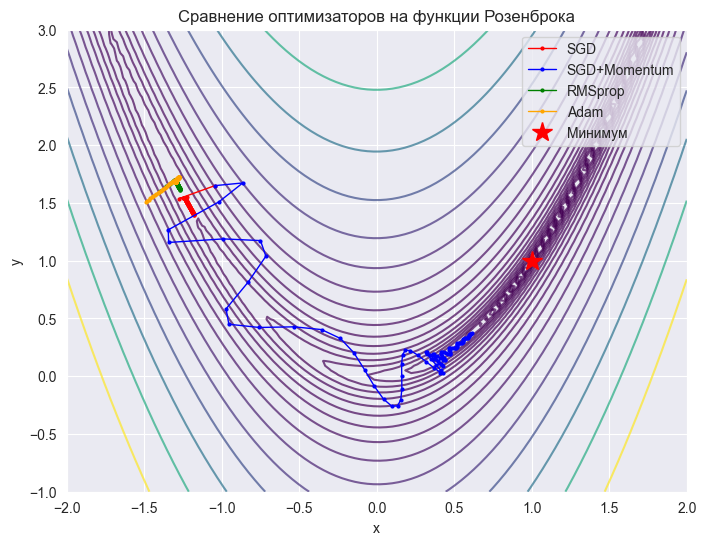

In [17]:
x0, y0 = -1.5, 1.5
steps = 100

# Словарь с оптимизаторами и их параметрами
optimizers = {
    'SGD': (torch.optim.SGD, {'lr': 0.001}),
    'SGD+Momentum': (torch.optim.SGD, {'lr': 0.001, 'momentum': 0.9}),
    'RMSprop': (torch.optim.RMSprop, {'lr': 0.01}),
    'Adam': (torch.optim.Adam, {'lr': 0.01})
}

trajectories = {}
for name, (opt_class, kwargs) in optimizers.items():
    xh, yh, fh = optimizer_trajectory(rosenbrock, x0, y0, opt_class, kwargs, steps)
    trajectories[name] = (xh, yh, fh)

# Построение
plt.figure(figsize=(8,6))
plt.contour(X, Y, Z_rosen, levels=np.logspace(-1, 3, 20), cmap='viridis', alpha=0.7)
colors = ['red', 'blue', 'green', 'orange']
for i, (name, (xh, yh, fh)) in enumerate(trajectories.items()):
    plt.plot(xh, yh, '.-', color=colors[i], linewidth=1, markersize=4, label=name)
plt.plot(1, 1, 'r*', markersize=15, label='Минимум')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Сравнение оптимизаторов на функции Розенброка')
plt.legend()
plt.show()

**Задание 5. Вопросы для анализа:**
- Какой оптимизатор быстрее достиг окрестности минимума?
- Как ведёт себя SGD без момента? Почему он "застревает" в овраге?
- Почему Adam и RMSprop работают лучше?
- Сравнить оптимизаторы по итоговому найденному значению минимизируемой функции.
- Сравнить времена работы (эффективность/производительность) оптимизаторов. Если на одинаковом количестве итераций они оказались примерно одинаковые, попробовать увеличить количество итераций так, чтобы 1-2 метода успели попасть в небольшую окрестность глобального минимума и сравнить методы по количеству этих итераций.


**Ответы:**
- Быстрее всех по числу итераций был `SGD+Momentum`.
- `SGD` идёт медленно и зигзагообразно вдоль оврага Розенброка, за то же кол-во шагов он проходит куда меньше растояния.
- `RMSprop` и `Adam` тоже продвигаются не так быстро, возмоджно дело больше в неоптимальном подборе параметров.
- Минимальное финальное значение нам дала `SGD+Momentum`, после `RMSprop`, `SGD` и `Adam`.
- По времени шаги методов выполняются примерно за одно и то же, тут больше измерения меняются в зависимости от кол-ва шагов. `SGD+Momentum` оказался наиболее эффективным по соотношению качества и скорости сходимости.

In [18]:
def optimizer_trajectory_1(func, x0, y0, optim_class, optim_kwargs, steps=100):
    """
    Метод для конкретного оптимизатора и конкретной оптимизируемой функции реализует градиентный спуск.
    optim_class: наименование класса оптимизатора строкой (SGD, Adam, RMSprop)
    optim_kwargs: словарь параметров, например {'lr':0.01, 'momentum':0.9}
    """
    x = torch.tensor(x0, requires_grad=True, dtype=torch.float32)
    y = torch.tensor(y0, requires_grad=True, dtype=torch.float32)
    eps = 0.05
    # Создаём оптимизатор, передав список параметров
    optimizer = optim_class([x, y], **optim_kwargs)

    x_hist, y_hist, f_hist = [], [], []

    for i in range(steps):
        optimizer.zero_grad()
        f = func(x, y)
        f.backward()
        # собственно обновление значений подбираемых параметров
        optimizer.step()

        if abs(x.item()-1)<eps and abs(y.item()-1)<eps:
            print("Количество итераций: "+str(i+1))
            break

        x_hist.append(x.item())
        y_hist.append(y.item())
        f_hist.append(f.item())

    return x_hist, y_hist, f_hist

Количество итераций: 623


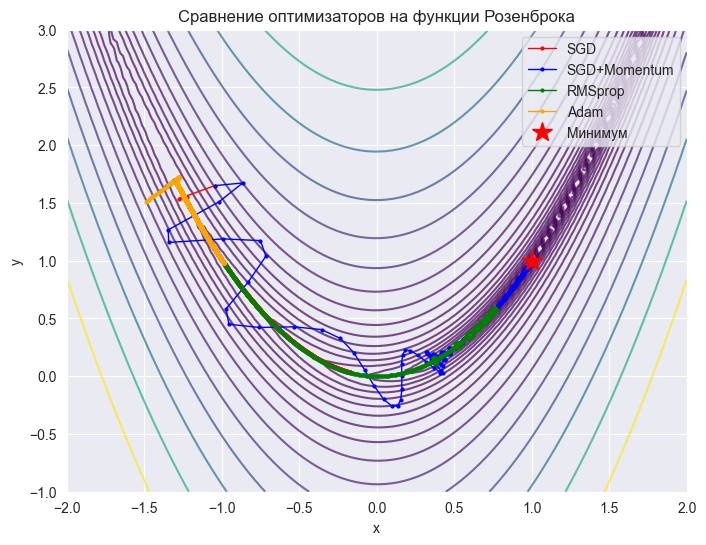

In [21]:
x0, y0 = -1.5, 1.5
steps = 1000

# Словарь с оптимизаторами и их параметрами
optimizers = {
    'SGD': (torch.optim.SGD, {'lr': 0.001}),
    'SGD+Momentum': (torch.optim.SGD, {'lr': 0.001, 'momentum': 0.9}),
    'RMSprop': (torch.optim.RMSprop, {'lr': 0.01}),
    'Adam': (torch.optim.Adam, {'lr': 0.01})
}

trajectories = {}
for name, (opt_class, kwargs) in optimizers.items():
    xh, yh, fh = optimizer_trajectory_1(rosenbrock, x0, y0, opt_class, kwargs, steps)
    trajectories[name] = (xh, yh, fh)

# Построение
plt.figure(figsize=(8,6))
plt.contour(X, Y, Z_rosen, levels=np.logspace(-1, 3, 20), cmap='viridis', alpha=0.7)
colors = ['red', 'blue', 'green', 'orange']
for i, (name, (xh, yh, fh)) in enumerate(trajectories.items()):
    plt.plot(xh, yh, '.-', color=colors[i], linewidth=1, markersize=4, label=name)
plt.plot(1, 1, 'r*', markersize=15, label='Минимум')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Сравнение оптимизаторов на функции Розенброка')
plt.legend()
plt.show()

### 4.2 Анимация траекторий (дополнительно)
Для наглядности можно создать анимацию движения точек. Ниже приведён код для создания GIF-анимации с помощью matplotlib.animation. Запустите эту ячейку, чтобы увидеть, как оптимизаторы "шагают" к минимуму.

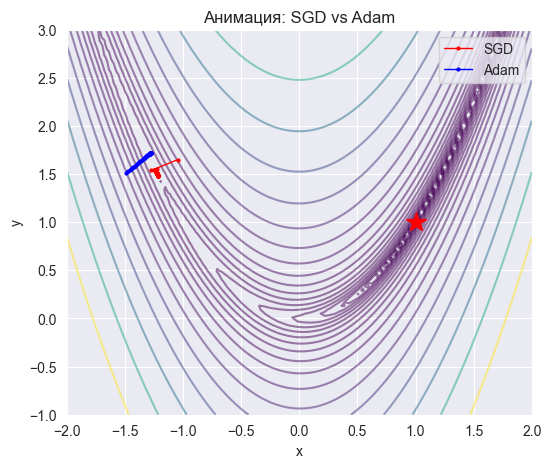

In [23]:
# Создаём анимацию для двух оптимизаторов: SGD и Adam
fig, ax = plt.subplots(figsize=(6,5))
ax.contour(X, Y, Z_rosen, levels=np.logspace(-1, 3, 20), cmap='viridis', alpha=0.5)
ax.plot(1, 1, 'r*', markersize=15)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Анимация: SGD vs Adam')

line_sgd, = ax.plot([], [], 'r.-', lw=1, markersize=4, label='SGD')
line_adam, = ax.plot([], [], 'b.-', lw=1, markersize=4, label='Adam')
ax.legend()

# Получаем траектории (первые steps точек)
steps_anim = 50  # возьмём первые 50 шагов для анимации
x_sgd, y_sgd = trajectories['SGD'][0][:steps_anim], trajectories['SGD'][1][:steps_anim]
x_adam, y_adam = trajectories['Adam'][0][:steps_anim], trajectories['Adam'][1][:steps_anim]

def init():
    line_sgd.set_data([], [])
    line_adam.set_data([], [])
    return line_sgd, line_adam

def animate(i):
    line_sgd.set_data(x_sgd[:i+1], y_sgd[:i+1])
    line_adam.set_data(x_adam[:i+1], y_adam[:i+1])
    return line_sgd, line_adam

anim = animation.FuncAnimation(fig, animate, init_func=init, frames=steps_anim, interval=100, blit=True)

# Показываем анимацию без требования ffmpeg
try:
    HTML(anim.to_html5_video())
except RuntimeError:
    HTML(anim.to_jshtml())

## 5. Влияние скорости обучения (learning rate) на сходимость

Проведём эксперимент: зафиксируем начальную точку (-1.5, 1.5) и оптимизатор SGD (без момента). Будем менять learning rate: очень маленький (0.0001), средний (0.001), большой (0.01) и слишком большой (0.1). Наблюдаем поведение.

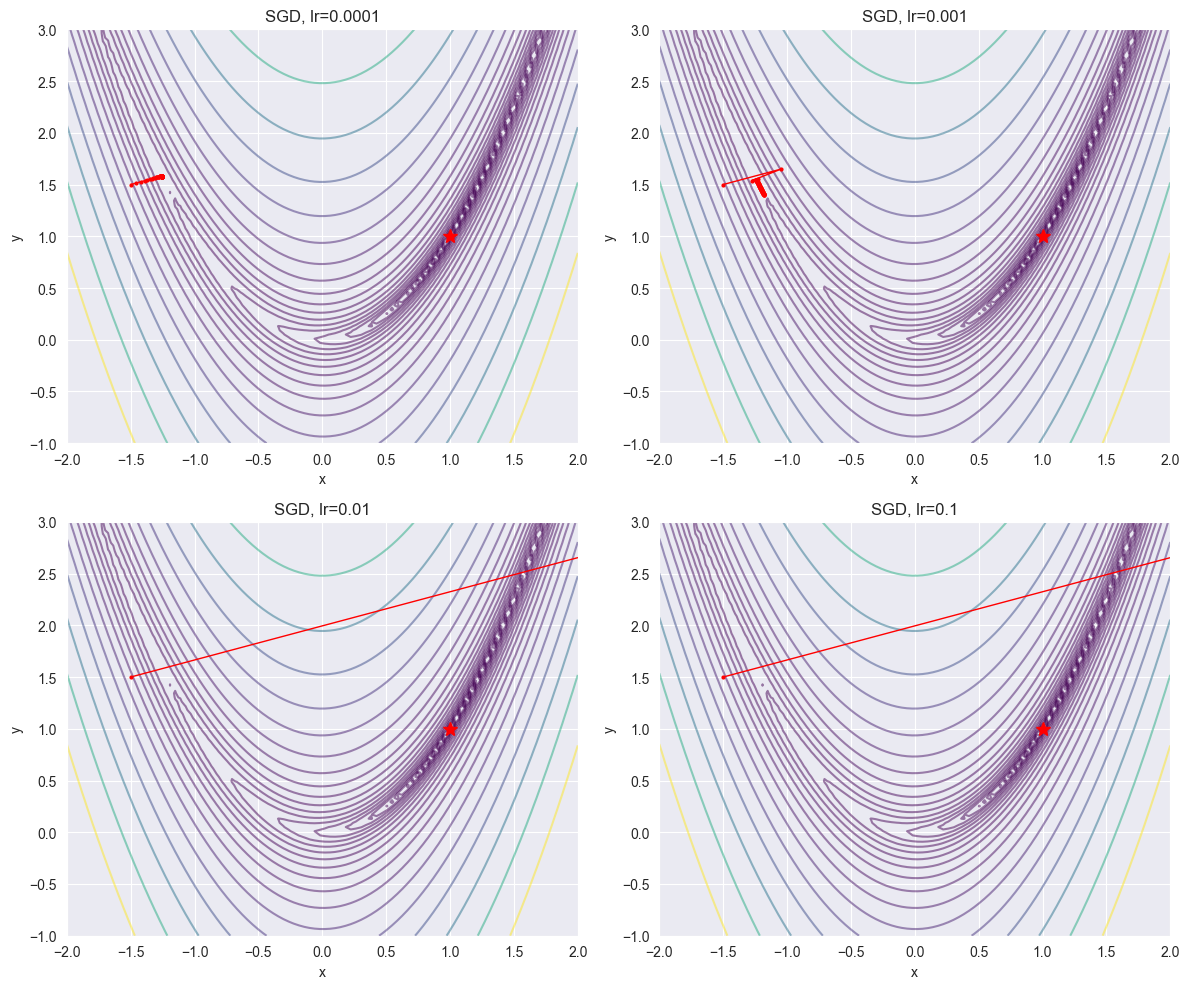

In [24]:
lrs_to_try = [0.0001, 0.001, 0.01, 0.1]
x0, y0 = -1.5, 1.5
steps = 100

plt.figure(figsize=(12,10))

for i, lr in enumerate(lrs_to_try):
    xh, yh, fh = sgd_trajectory(rosenbrock, x0, y0, lr, steps)
    plt.subplot(2,2,i+1)
    plt.contour(X, Y, Z_rosen, levels=np.logspace(-1, 3, 20), cmap='viridis', alpha=0.5)
    plt.plot(xh, yh, 'r.-', markersize=4, linewidth=1)
    plt.plot(1, 1, 'r*', markersize=10)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'SGD, lr={lr}')
    plt.xlim(-2,2)
    plt.ylim(-1,3)

plt.tight_layout()
plt.show()

**Обсуждение:**
- При очень маленьком LR (0.0001) алгоритм не успевает дойти до минимума за 100 шагов.
- При LR=0.001 траектория медленно сползает в овраг и движется к минимуму.
- При LR=0.01 шаги больше, но из-за оврага траектория может "перепрыгивать" и колебаться.
- При LR=0.1 градиентный спуск расходится: шаги становятся настолько большими, что точка улетает за пределы графика. Это иллюстрация "взрыва градиентов" (хотя здесь не градиенты взрываются, а слишком большой шаг).

**Задание 6.** Для функции Химмельблау и начальной точки (0, 0) подберите такое значение learning rate для SGD, чтобы алгоритм сошёлся к одному из минимумов, но при этом траектория была "интересной" (например, с колебаниями). Попробуйте также очень большое LR и посмотрите, куда улетает точка.

In [ ]:
# Ваш эксперимент с Химмельблау и разными LR


## **6. Итоги занятия**

* Что нового узнали? (навыки/умения/знания).
* Что добавить/убрать/расписать подробнее/усложнить/упростить и т.д.
